<a href="https://colab.research.google.com/github/AndrijaM06/ml-product-category-prediction/blob/main/product_category_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predikcija kategorije proizvoda na osnovu naslova

Ova sveska sadrži kompletnu analizu, čišćenje podataka, inženjering karakteristika,
treniranje i evaluaciju modela za automatsku klasifikaciju proizvoda po kategoriji,
na osnovu naziva proizvoda (Product Title).

## 1. Učitavanje i osnovni pregled podataka

In [8]:
import pandas as pd

# Load dataset from GitHub
url = "https://raw.githubusercontent.com/AndrijaM06/ml-product-category-prediction/main/data/products.csv"
df = pd.read_csv(url)

# Print shape
print("Dataset shape (rows, columns):", df.shape)

# Show first 5 rows
print("\nFirst 5 rows:")
display(df.head())

# Show column data types and non-null counts
print("\nDataset info:")
df.info()

Dataset shape (rows, columns): (35311, 8)

First 5 rows:


,product ID,Product Title,Merchant ID,Category Label,_Product Code,Number_of_Views,Merchant Rating,Listing Date
0,1,apple iphone 8 plus 64gb silver,1,Mobile Phones,QA-2276-XC,860.0,2.5,5/10/2024
1,2,apple iphone 8 plus 64 gb spacegrau,2,Mobile Phones,KA-2501-QO,3772.0,4.8,12/31/2024
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,Mobile Phones,FP-8086-IE,3092.0,3.9,11/10/2024
3,4,apple iphone 8 plus 64gb space grey,4,Mobile Phones,YI-0086-US,466.0,3.4,5/2/2022
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,Mobile Phones,NZ-3586-WP,4426.0,1.6,4/12/2023



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35311 entries, 0 to 35310
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   product ID       35311 non-null  int64  
 1   Product Title    35139 non-null  object 
 2   Merchant ID      35311 non-null  int64  
 3    Category Label  35267 non-null  object 
 4   _Product Code    35216 non-null  object 
 5   Number_of_Views  35297 non-null  float64
 6   Merchant Rating  35141 non-null  float64
 7    Listing Date    35252 non-null  object 
dtypes: float64(2), int64(2), object(4)
memory usage: 2.2+ MB


## 2. Čišćenje naziva kolona

Primeto sam da nazivi kolona sadrže suvišne razmake

Standardizujemo ih pre dalje analize

In [9]:
print("Original columns:", df.columns.tolist())

df.columns = [c.strip() for c in df.columns]

print("Cleaned columns:", df.columns.tolist())

Original columns: ['product ID', 'Product Title', 'Merchant ID', ' Category Label', '_Product Code', 'Number_of_Views', 'Merchant Rating', ' Listing Date  ']
Cleaned columns: ['product ID', 'Product Title', 'Merchant ID', 'Category Label', '_Product Code', 'Number_of_Views', 'Merchant Rating', 'Listing Date']


## 3. Provera nedostajućih vrednosti

Pre nego što bilo šta modelujemo, proveravamo ima li praznih vrednosti i gde se nalaze.

In [10]:
print("Missing values per column:")
print(df.isna().sum())

Missing values per column:
product ID           0
Product Title      172
Merchant ID          0
Category Label      44
_Product Code       95
Number_of_Views     14
Merchant Rating    170
Listing Date        59
dtype: int64


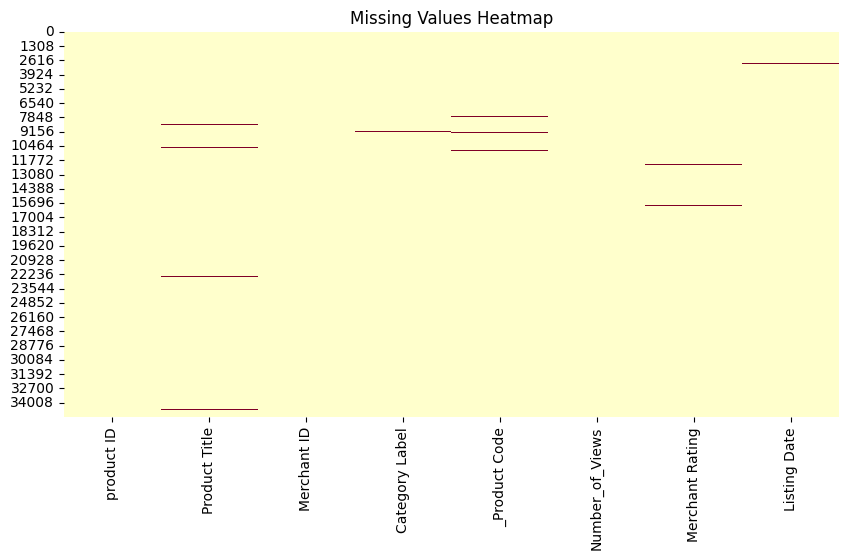

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.heatmap(df.isna(), cbar=False, cmap="YlOrRd")
plt.title("Missing Values Heatmap")
plt.show()

## 4. Analiza ciljne kolone: Category Label

Kolona `Category Label` predstavlja ciljnu vrednost koju model treba da predviđa.
Proveravamo koje sve vrednosti postoje i da li su konzistentne.

In [12]:
category_counts = df['Category Label'].value_counts()

print("Category distribution (counts):")
print(category_counts)

Category distribution (counts):
Category Label
Fridge Freezers     5495
Washing Machines    4036
Mobile Phones       4020
CPUs                3771
TVs                 3564
Fridges             3457
Dishwashers         3418
Digital Cameras     2696
Microwaves          2338
Freezers            2210
fridge               123
CPU                   84
Mobile Phone          55
Name: count, dtype: int64


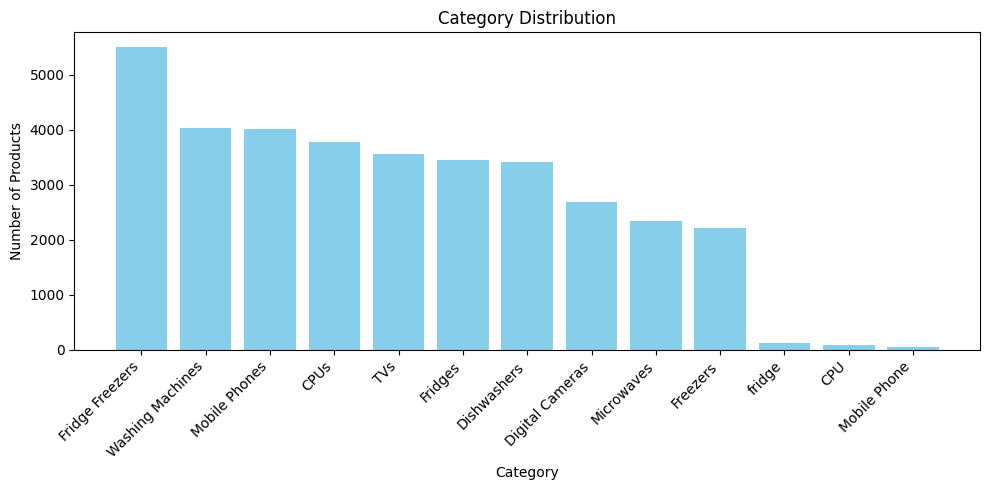

In [13]:
plt.figure(figsize=(10, 5))
plt.bar(category_counts.index, category_counts.values, color='skyblue')
plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Products")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Zapažanja iz EDA faze

- Dataset sadrži **35.311** redova i **8** kolona.
- Kolone `Product Title`, `Category Label`, `_Product Code`, `Number_of_Views` i
  `Merchant Rating` imaju nedostajuće vrednosti.
- Kolona `Category Label` sadrži **nekonzistentne, duplirane vrednosti** za iste
  kategorije, npr.:
  - `Fridges` i `fridge`
  - `CPUs` i `CPU`
  - `Mobile Phones` i `Mobile Phone`
- Ove vrednosti moramo standardizovati pre treniranja modela, jer bi ih model
  inače tretirao kao različite klase.